## Exercise 2 - Multiple Input Graph

In [2]:
from typing import TypedDict, List
from langgraph.graph import StateGraph
import math

In [3]:
class AgentState(TypedDict):
    name: str
    values: List[int]
    operation: str
    result: str

In [4]:
def operation_node(state: AgentState) -> AgentState:
    if state["operation"] == "*":
        result = math.prod(state["values"])

    elif state["operation"] == "+":
        result = sum(state["values"])

    else:
        state["result"] = f"Hi {state['name']}, your operation is not supported."
        return state

    state["result"] = f"Hi {state['name']}, your answer is: {result}"
    return state

In [5]:
graph = StateGraph(AgentState)

graph.add_node('operation', operation_node)

graph.set_entry_point("operation")

graph.set_finish_point("operation")

app = graph.compile()

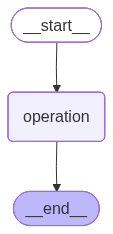

In [6]:
from IPython.display import display, Image
display(Image(app.get_graph().draw_mermaid_png()))

In [7]:
result = app.invoke({"name": "Jack Sparrow", "values":[1,2,3,4], "operation": "*"})

In [8]:
print(result["result"])

Hi Jack Sparrow, your answer is: 24
